In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df= pd.read_csv(url)

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print(df.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [4]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print("Data is now 100% clean.")

Data is now 100% clean.


In [5]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

df['bedroom_ratio'] = df['total_bedrooms'] / df['total_rooms']

df['price_per_room'] = df['median_house_value'] / df['total_rooms']

df[['median_house_value','rooms_per_household','price_per_room']].head()



,median_house_value,rooms_per_household,price_per_room
0,452600.0,6.984127,514.318182
1,358500.0,6.238137,50.500070
2,352100.0,8.288136,240.013633
3,341300.0,5.817352,267.896389
4,342200.0,6.281853,210.325753


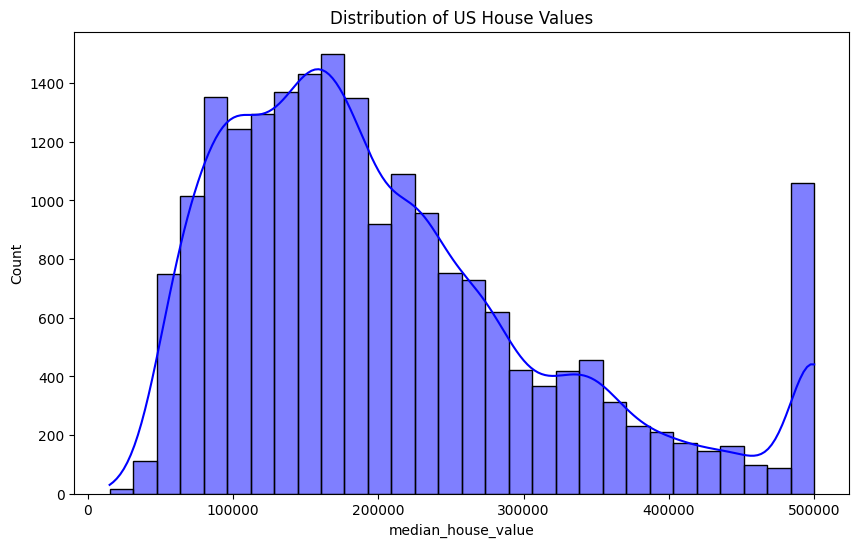

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['median_house_value'], bins=30, kde=True, color='blue')
plt.title('Distribution of US House Values')
plt.show()

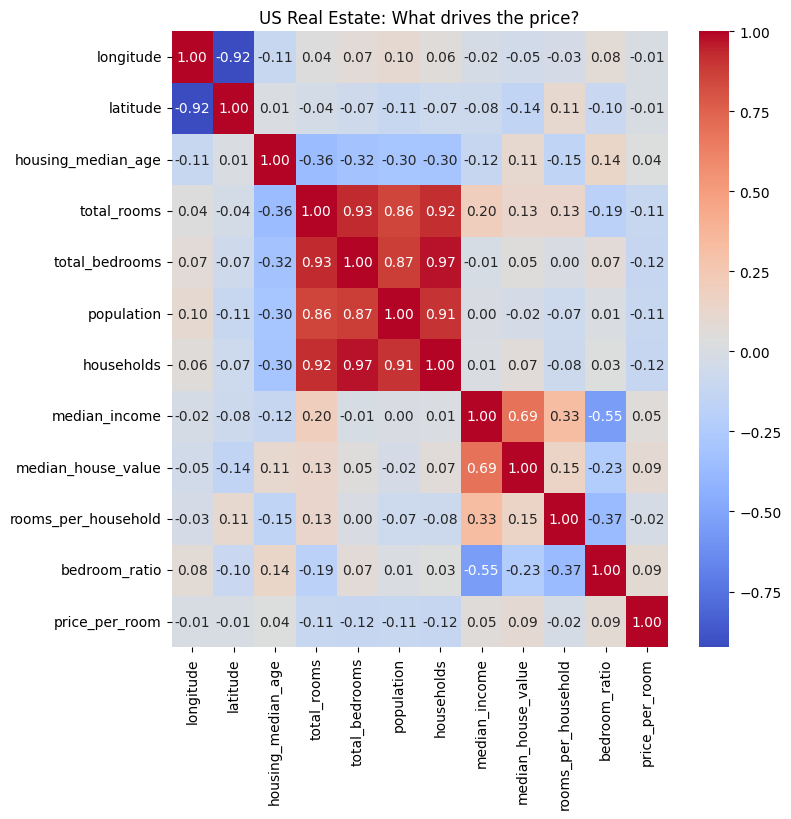

In [10]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('US Real Estate: What drives the price?')
plt.show()

/tmp/ipython-input-131639770.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='viridis')


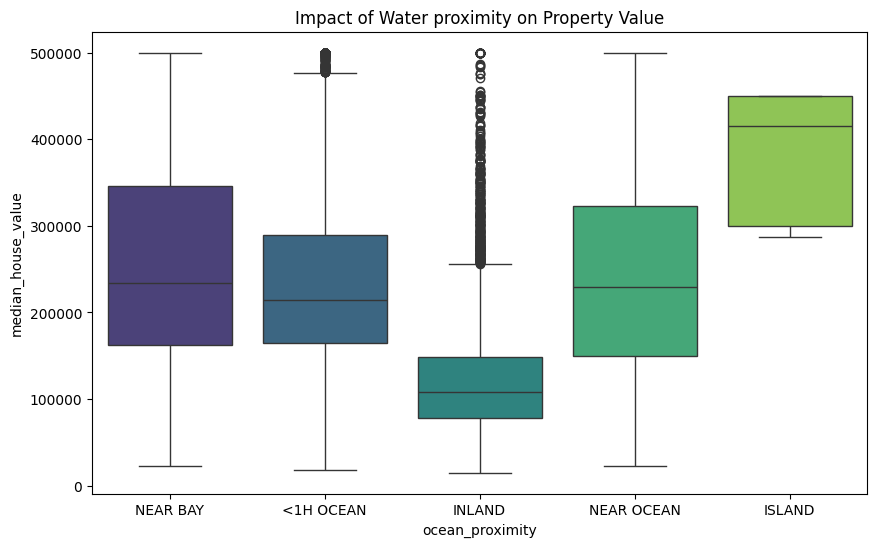

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='viridis')
plt.title('Impact of Water proximity on Property Value')
plt.show()

